<a href="https://colab.research.google.com/github/mosesdorri-gif/BIG-PROJECT/blob/main/ML_P_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### IMPORTS

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Datasets/bank_churn_dataset.csv')

In [ ]:
df.head()

,id,full_name,credit_sco,gender,age,occupation,balance,monthly_ir,address,origin_province,...,last_transaction_month,created_date,exit,customer_segment,engagement_score,loyalty_level,digital_behavior,risk_score,risk_segment,cluster_group
0,1,Đặng Văn Vũ,725,male,55,Chủ Doanh nghiệp nhỏ,177306004,121000000,Phường An Hội (BT),TP. Hồ Chí Minh,...,91038993,27/02/2025,False,Priority,90,Bronze,mobile,0.0359,Low,4
1,2,Bùi Hữu Phúc,689,male,45,Nội trợ/Sinh viên,1927416,5000000,Phường Bến Thành (Q1),Đồng Nai,...,3255569,29/07/2021,False,Mass,63,Gold,mobile,0.2664,Low,2
2,3,Lê Văn Mai,702,female,44,Chủ Doanh nghiệp nhỏ,304931745,109000000,Phường Hòa Bình (Q11),TP. Hồ Chí Minh,...,0,03/03/2021,False,Priority,36,Silver,offline,0.1343,Low,4
3,4,Dương Trần Nhiên,766,male,44,Chủ Doanh nghiệp nhỏ,50615501,79000000,Phường 7 (Q7),TP. Hồ Chí Minh,...,0,12/02/2022,False,Priority,23,Bronze,offline,0.2185,Low,4
4,5,Dương Thu Linh,677,female,77,Giáo viên/Giảng viên,40532432,25000000,Phường Thắng Lợi (Q10),TP. Hồ Chí Minh,...,0,24/07/2022,False,Emerging,23,Bronze,offline,0.2942,Low,2


In [ ]:
df = df.drop('id',axis = 1)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   full_name               80000 non-null  object 
 1   credit_sco              80000 non-null  int64  
 2   gender                  80000 non-null  object 
 3   age                     80000 non-null  int64  
 4   occupation              80000 non-null  object 
 5   balance                 80000 non-null  int64  
 6   monthly_ir              80000 non-null  int64  
 7   address                 80000 non-null  object 
 8   origin_province         80000 non-null  object 
 9   tenure_ye               80000 non-null  int64  
 10  married                 80000 non-null  int64  
 11  nums_card               80000 non-null  int64  
 12  nums_service            80000 non-null  int64  
 13  active_member           80000 non-null  bool   
 14  last_active_date        80000 non-null

In [ ]:
np.transpose(df.describe())

,count,mean,std,min,25%,50%,75%,max
credit_sco,80000.0,6.843211e+02,5.116973e+01,4.950000e+02,6.490000e+02,6.820000e+02,7.180000e+02,8.000000e+02
age,80000.0,4.938186e+01,1.506748e+01,2.000000e+01,3.800000e+01,4.700000e+01,5.800000e+01,9.000000e+01
balance,80000.0,6.118320e+07,8.868620e+07,4.086630e+05,1.462592e+07,3.090276e+07,6.960994e+07,1.000000e+09
monthly_ir,80000.0,3.778820e+07,3.655107e+07,3.000000e+06,1.400000e+07,2.300000e+07,4.700000e+07,2.160000e+08
tenure_ye,80000.0,1.777250e+00,1.315828e+00,0.000000e+00,1.000000e+00,2.000000e+00,3.000000e+00,4.000000e+00
married,80000.0,9.708250e-01,6.946977e-01,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,3.000000e+00
nums_card,80000.0,2.634688e+00,1.218556e+00,1.000000e+00,2.000000e+00,2.000000e+00,3.000000e+00,5.000000e+00
nums_service,80000.0,3.564425e+00,2.002448e+00,1.000000e+00,2.000000e+00,3.000000e+00,5.000000e+00,8.000000e+00
last_transaction_month,80000.0,8.831755e+06,3.378683e+07,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,6.000000e+08
engagement_score,80000.0,3.172540e+01,2.347486e+01,7.000000e+00,1.600000e+01,2.200000e+01,3.800000e+01,1.000000e+02


### VISUALIZATIONS

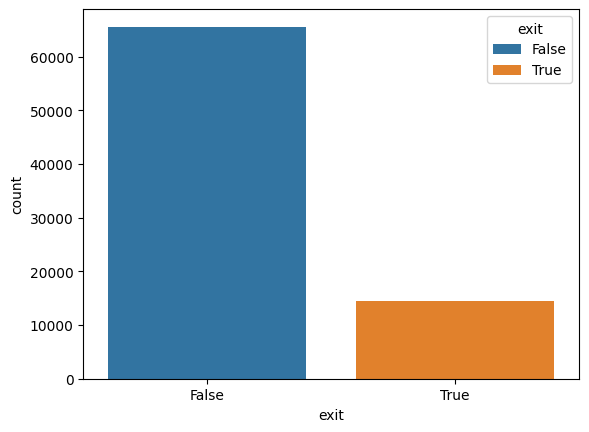

In [ ]:
sns.countplot(x = 'exit', legend = True, data = df, hue = 'exit');

<Axes: xlabel='risk_score', ylabel='credit_sco'>

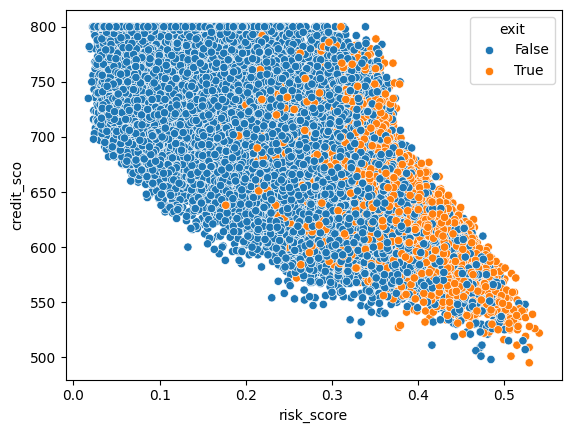

In [ ]:
sns.scatterplot(x = 'risk_score', y = 'credit_sco', data =df,hue = 'exit', )

In [ ]:
sf  = df[['credit_sco', 'balance', 'risk_score','engagement_score','nums_card']].corr()

<Axes: >

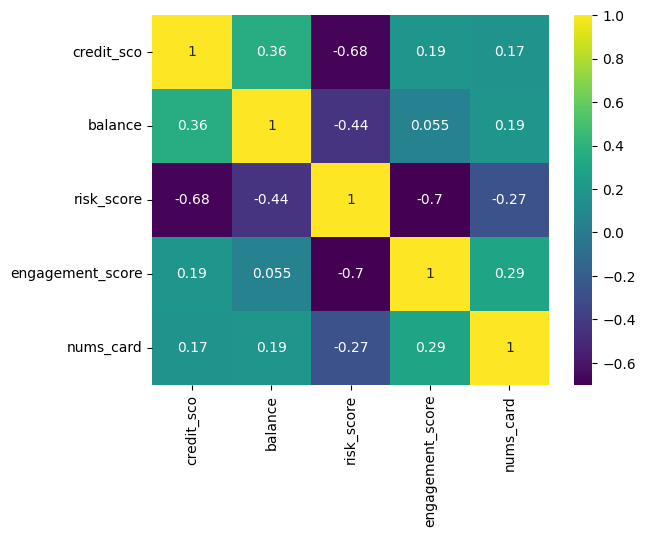

In [ ]:
sns.heatmap(sf,annot  =True,cmap = 'viridis')

### FEATURE ENGINEERING/SCALING

In [ ]:
X = df.drop(['exit','full_name'], axis = 1)
X= pd.get_dummies(X,drop_first= True)

In [ ]:
y = df['exit']

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.15, random_state=42)
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_validate
from sklearn.metrics import accuracy_score, precision_score,f1_score,recall_score,roc_auc_score
from sklearn.metrics import classification_report,confusion_matrix,ConfusionMatrixDisplay,RocCurveDisplay,roc_curve, auc

## MODEL CREATION

In [ ]:
tree = DecisionTreeClassifier()


In [ ]:
tree.fit(X_train,y_train);

In [ ]:
y1 = tree.predict(X_test)

In [ ]:
print(classification_report(y_test,y1))

              precision    recall  f1-score   support

       False       0.86      0.89      0.87      9773
        True       0.43      0.38      0.40      2227

    accuracy                           0.79     12000
   macro avg       0.65      0.63      0.64     12000
weighted avg       0.78      0.79      0.79     12000



In [ ]:
cm1 = confusion_matrix(y_test,y1)

<Figure size 500x500 with 0 Axes>

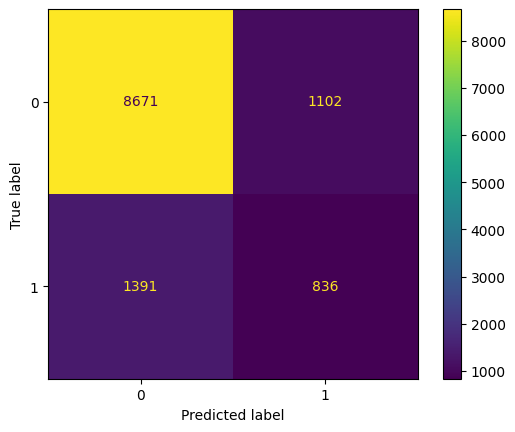

In [ ]:

fig = plt.figure(figsize=(5,5))
ConfusionMatrixDisplay(confusion_matrix=cm1).plot()


In [ ]:
m2 = RandomForestClassifier()


In [ ]:
m2.fit(X_train, y_train);

In [ ]:
y2 = m2.predict(X_test)

In [ ]:
print(classification_report(y_test,y2))

              precision    recall  f1-score   support

       False       0.86      0.97      0.91      9773
        True       0.68      0.28      0.40      2227

    accuracy                           0.84     12000
   macro avg       0.77      0.63      0.65     12000
weighted avg       0.82      0.84      0.81     12000



In [ ]:
cm2 = confusion_matrix(y_test,y2)

<Figure size 500x500 with 0 Axes>

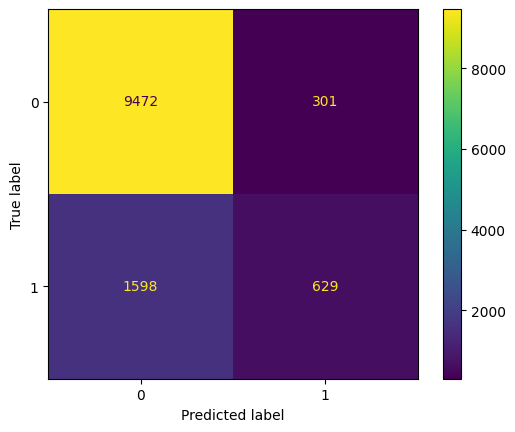

In [ ]:
fig = plt.figure(figsize = (5,5))
ConfusionMatrixDisplay(confusion_matrix=cm2).plot()

In [ ]:
m3 = GradientBoostingClassifier()
m3.fit(X_train,y_train);

In [ ]:
y3 = m3.predict(X_test)

In [ ]:
print(classification_report(y_test,y3))

              precision    recall  f1-score   support

       False       0.86      0.96      0.91      9773
        True       0.65      0.32      0.43      2227

    accuracy                           0.84     12000
   macro avg       0.76      0.64      0.67     12000
weighted avg       0.82      0.84      0.82     12000



In [ ]:
cm3 = confusion_matrix(y_test,y3)

<Figure size 500x500 with 0 Axes>

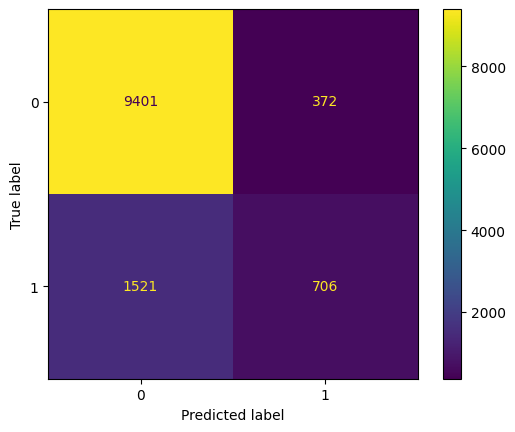

In [ ]:
fig = plt.figure(figsize = (5,5))
ConfusionMatrixDisplay(confusion_matrix = cm3).plot()

In [ ]:
m4 = LogisticRegression()

In [ ]:
m4.fit(X_train,y_train);

In [ ]:
y4 = m4.predict(X_test)

In [ ]:
print(classification_report(y_test,y4))

              precision    recall  f1-score   support

       False       0.86      0.94      0.90      9773
        True       0.55      0.35      0.43      2227

    accuracy                           0.83     12000
   macro avg       0.71      0.64      0.66     12000
weighted avg       0.80      0.83      0.81     12000



In [ ]:
cm4 = confusion_matrix(y_test,y4)

<Figure size 500x500 with 0 Axes>

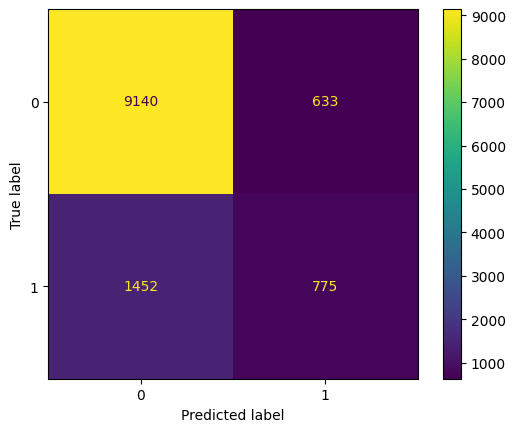

In [ ]:
fig = plt.figure(figsize = (5,5))


CM4 = ConfusionMatrixDisplay(confusion_matrix=cm4).plot()


### MODEL EVALUATION!

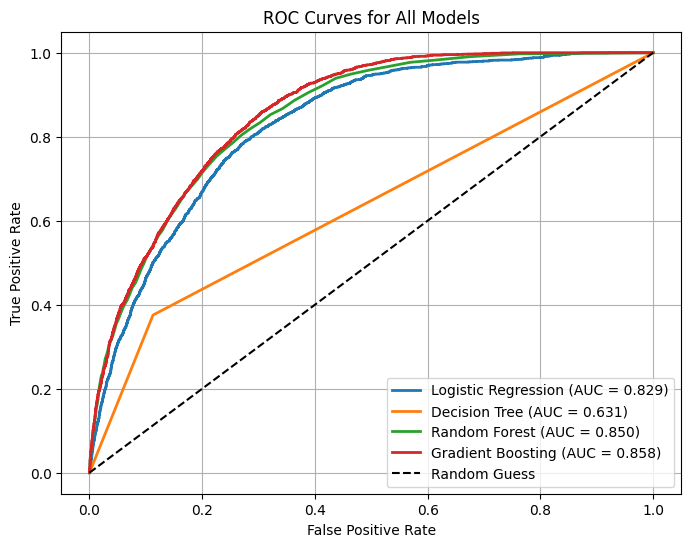

In [ ]:
models = {
    "Logistic Regression": m4,
    "Decision Tree": tree,
    "Random Forest": m2 ,
    "Gradient Boosting": m3,

}

plt.figure(figsize=(8,6))

for name, model in models.items():
s
    y_prob = model.predict_proba(X_test)[:, 1]


    fpr, tpr, _ = roc_curve(y_test, y_prob)


    auc = roc_auc_score(y_test, y_prob)


    plt.plot(fpr, tpr, linewidth=2,
             label=f"{name} (AUC = {auc:.3f})")

plt.plot([0,1], [0,1], 'k--', label='Random Guess')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for All Models")
plt.legend(loc="lower right")
plt.grid(True)

plt.show()

In [ ]:
import joblib

joblib.dump(m3, "gradient_boosting_model.pkl")

['gradient_boosting_model.pkl']

In [ ]:
import sklearn
import xgboost

print(sklearn.__version__)
print(xgboost.__version__)

1.6.1
3.3.0
